# Exercise - Duration

#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$

## 1 Stylized Duration and Convexity

Consider a bond issued today, with
* 10 years to maturity
* coupon rate of 3%
* yield to maturity (semiannual) is 5\%


### 1.1.

Calculate duration as given in the formula.

In [17]:
maturity = 10
coupon_rate = 0.03
ytm = 0.05
frequency = 2  # semiannual

def bond_duration(maturity, coupon_rate, ytm, frequency):
    periods = maturity * frequency
    coupon = coupon_rate / frequency
    ytm_period = ytm / frequency

    cash_flows = [coupon] * (periods - 1) + [coupon + 1]
    discount_factors = [(1 + ytm_period) ** -t for t in range(1, periods + 1)]
    pv_cash_flows = [cf * df for cf, df in zip(cash_flows, discount_factors)]
    bond_price = sum(pv_cash_flows)

    weighted_times = [t * pv_cf for t, pv_cf in enumerate(pv_cash_flows, start=1)]
    duration = sum(weighted_times) / bond_price / frequency  # convert to years

    return duration

duration = bond_duration(maturity, coupon_rate, ytm, frequency)
print(f"Duration with 3% coupon: {duration:.4f} years")

Duration with 3% coupon: 8.5709 years


### 1.2.
Re-calculate the duration but now assuming the coupon is 7%. (Leave the other parameters the same.)

In [18]:
coupon_rate = 0.07
duration = bond_duration(maturity, coupon_rate, ytm, frequency)
print(f"Duration with 7% coupon: {duration:.4f} years")

Duration with 7% coupon: 7.5648 years


### 1.3.
Re-calculate the duration but now assuming the coupon is 5%. (Leave the other parameters the same.)

In [19]:
coupon_rate = 0.05
duration = bond_duration(maturity, coupon_rate, ytm, frequency)
print(f"Duration with 5% coupon: {duration:.4f} years")

Duration with 5% coupon: 7.9894 years


### 1.4.
Compare the answers. How does coupon rate impact duration. Explain.

As the coupon increases:
- More cash flows arrive earlier.
- The weighted average timing of payments shifts forward.
- Therefore, duration decreases.
$$D_{7\%} < D_{5\%} < D_{3\%}$$

Higher coupon -> lower interest-rate sensitivity.

***

# 2 Hedging Duration

Use data from `../data/treasury_ts_duration_2025-05-30.xlsx`.

The file contains time-series information on two treasuries. 

In [20]:
import pandas as pd

In [21]:
QUOTE_DATE = '2025-05-30'
filepath = f'data/treasury_ts_duration_{QUOTE_DATE}.xlsx'

data = pd.read_excel(filepath,sheet_name='database')
data_info =  data.drop_duplicates(subset='KYTREASNO', keep='first').set_index('KYTREASNO')
data_info[['type','issue date','maturity date','cpn rate']]

,type,issue date,maturity date,cpn rate
KYTREASNO,,,,
207391,note,2019-08-15,2029-08-15,1.625
207392,bond,2019-08-15,2049-08-15,2.250


You will largely focus on the sheets which give the timeseries of prices and durations for each of the two securities, as shown in the following code.

In [22]:
SHEET_CLEAN = 'clean price'
SHEET_DIRTY = 'dirty price'
SHEET_DURATION = 'duration'
INDEX_NAME = 'quote date'

clean = pd.read_excel(filepath,sheet_name=SHEET_CLEAN).set_index(INDEX_NAME)
dirty = pd.read_excel(filepath,sheet_name=SHEET_DIRTY).set_index(INDEX_NAME)
duration = pd.read_excel(filepath,sheet_name=SHEET_DURATION).set_index(INDEX_NAME)

Set prices to clean or dirty...

In [23]:
USE_CLEAN = True

if USE_CLEAN:
    price = clean
else:
    price = dirty

In [24]:
display(price)

,207391,207392
quote date,,
2019-08-09,98.882812,99.789062
2019-08-12,99.796875,102.554688
2019-08-13,99.281250,101.867188
2019-08-14,100.406250,105.179688
2019-08-15,100.882812,106.234375
...,...,...
2025-05-23,90.904697,59.948053
2025-05-27,91.035156,60.871094
2025-05-28,90.910156,60.542969


Duration...

In [25]:
display(duration)

,207391,207392
quote date,,
2019-08-09,9.289497,22.000102
2019-08-12,9.285468,22.118496
2019-08-13,9.280314,22.084308
2019-08-14,9.282750,22.228549
2019-08-15,9.282163,22.270910
...,...,...
2025-05-23,4.081232,16.706728
2025-05-27,4.070393,16.764143
2025-05-28,4.067509,16.736880


### 2.1.

Suppose you have a portfolio of `10,000` USD long in security `207391` on the first day of the sample.

If you want to manage interest rate exposure using duration, how large of a short position should you hold in `207392`?

In [27]:
# -------------------------
# 2.1: Hedge ratio on the first day
# -------------------------

SEC_LONG = 207391
SEC_HEDGE = 207392
LONG_USD = 10_000

# align indices (just in case)
idx = price.index.intersection(duration.index)
price2 = price.loc[idx, [SEC_LONG, SEC_HEDGE]].copy()
dur2 = duration.loc[idx, [SEC_LONG, SEC_HEDGE]].copy()

# first date in the sample
t0 = idx[0]

P1_0 = float(price2.loc[t0, SEC_LONG])
P2_0 = float(price2.loc[t0, SEC_HEDGE])
D1_0 = float(dur2.loc[t0, SEC_LONG])
D2_0 = float(dur2.loc[t0, SEC_HEDGE])

# If you're $10,000 long in SEC_LONG, number of "bonds" (per $100 par quotes) held is:
# (One unit costs P dollars, since prices are per $100 face.)
q1_0 = LONG_USD / P1_0

# Duration-neutral hedge: q1*P1*D1 + q2*P2*D2 = 0  =>  q2 = -(q1*P1*D1)/(P2*D2)
q2_0 = -(q1_0 * P1_0 * D1_0) / (P2_0 * D2_0)

print(f"First date: {t0}")
print(f"Long position:   q1 = {q1_0:,.6f} units of {SEC_LONG} (market value ${LONG_USD:,.2f})")
print(f"Hedge position:  q2 = {q2_0:,.6f} units of {SEC_HEDGE} (negative means short)")
print(f"Check net duration exposure (approx): {q1_0*P1_0*D1_0 + q2_0*P2_0*D2_0: .6f}")


First date: 2019-08-09 00:00:00
Long position:   q1 = 101.129810 units of 207391 (market value $10,000.00)
Hedge position:  q2 = -42.314047 units of 207392 (negative means short)
Check net duration exposure (approx):  0.000000


### 2.2.

Step through the time-series, doing the following:

* Starting at the end of the first day, set the hedged position according to the relative given durations.
* Use the second day's price data to evaluate the net profit or loss of the hedged position.
* Reset the the hedged position using the end-of-second-day durations. Again fix the long position of security `207391` to be `10,000`.
* Repeat throughout the timeseries.

Calculate the daily profit and loss (PnL) for the
* dynamically hedged position constructed above.
* long-only position, (still at `10,000` throughout.)

(You might check to verify that the net duration is zero at all dates.)

Report...
* the cumulative PnL of both strategies via a plot.
* the (daily) mean, standard deviation, min, and max of the PnL in a table.

Net duration exposure (first 5 dates):


quote date
2019-08-09    0.000000e+00
2019-08-12   -1.455192e-11
2019-08-13   -1.455192e-11
2019-08-14    0.000000e+00
2019-08-15    1.455192e-11
dtype: float64

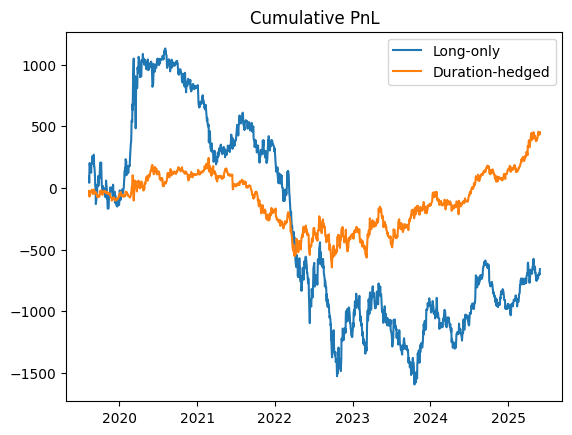

,mean,std,min,max
Long-only,-0.453534,43.282811,-321.203791,276.272207
Hedged,0.310452,20.851860,-98.341110,118.431025


In [28]:
import matplotlib.pyplot as plt

# -------------------------
# 2.2: Dynamic daily hedging + PnL
# -------------------------

# We rebalance at the END of each day t using that day's prices/durations,
# then measure next-day PnL from t -> t+1 using the held quantities.

dates = idx.to_list()

q1 = pd.Series(index=idx, dtype=float)  # units of long bond held after rebalance at date t
q2 = pd.Series(index=idx, dtype=float)  # units of hedge bond held after rebalance at date t

# set positions each day to keep the LONG market value fixed at LONG_USD,
# and hedge to duration-neutral that day
q1[:] = LONG_USD / price2[SEC_LONG]
q2[:] = -(q1 * price2[SEC_LONG] * dur2[SEC_LONG]) / (price2[SEC_HEDGE] * dur2[SEC_HEDGE])

# daily PnL series (indexed by the "next day" date)
pnl_long = pd.Series(index=idx[1:], dtype=float)
pnl_hedged = pd.Series(index=idx[1:], dtype=float)

for i in range(1, len(idx)):
    t_prev = idx[i - 1]
    t_now = idx[i]

    # quantities held over the interval (t_prev -> t_now)
    q1_prev = float(q1.loc[t_prev])
    q2_prev = float(q2.loc[t_prev])

    dP1 = float(price2.loc[t_now, SEC_LONG] - price2.loc[t_prev, SEC_LONG])
    dP2 = float(price2.loc[t_now, SEC_HEDGE] - price2.loc[t_prev, SEC_HEDGE])

    pnl_long.loc[t_now] = q1_prev * dP1
    pnl_hedged.loc[t_now] = q1_prev * dP1 + q2_prev * dP2

# quick “net duration” check (should be ~0 each day by construction)
net_dur_exposure = q1 * price2[SEC_LONG] * dur2[SEC_LONG] + q2 * price2[SEC_HEDGE] * dur2[SEC_HEDGE]
print("Net duration exposure (first 5 dates):")
display(net_dur_exposure.head())

# cumulative PnL plot
plt.figure()
plt.plot(pnl_long.cumsum(), label="Long-only")
plt.plot(pnl_hedged.cumsum(), label="Duration-hedged")
plt.title("Cumulative PnL")
plt.legend()
plt.show()

# table of daily PnL stats
pnl_stats = pd.DataFrame(
    {
        "mean": [pnl_long.mean(), pnl_hedged.mean()],
        "std":  [pnl_long.std(),  pnl_hedged.std()],
        "min":  [pnl_long.min(),  pnl_hedged.min()],
        "max":  [pnl_long.max(),  pnl_hedged.max()],
    },
    index=["Long-only", "Hedged"]
)
display(pnl_stats)


### 2.3.

Give two reasons that the daily PnL is not always zero for the hedged position given that we have hedged the duration.

1. **Convexity**: Duration is a linear approximation of price sensitivity to interest rate changes. However, bond prices exhibit convexity, meaning that the relationship between price and yield is curved. As a result, even if the duration is perfectly hedged, changes in interest rates can lead to non-linear price movements that are not fully captured by duration alone.
2. **Changing Yield Curve**: The yield curve can shift in a non-parallel manner. Duration hedging typically assumes parallel shifts in interest rates, but in reality, different maturities can experience different rate changes. This can lead to mismatches in the hedged position, resulting in non-zero PnL.

### 2.4. 
The PnL above doesn't account for the coupons.

Calculate a dataframe indexed by dates with columns for the two treasuries with values of coupon payments. 
* Recall that the stated coupon rate is semiannual, so at any give coupon date, it pays half the stated rate.
* Figure out the coupon dates by using the `data` tab and looking for dates where `acc int` goes down. Recall that accrued interest measures the portion of the coupon period that has passed. So when this resets, it is because the coupon has been paid.

Report the first 5 dates that a coupon is paid (by either bond).

In [31]:
# -------------------------
# 2.4: Build a coupon-cashflow dataframe indexed by quote dates
# -------------------------

# We will create a coupon payment schedule for each security using issue/maturity dates,
# then map each coupon payment date to the next available quote date in the dataset.

def semiannual_coupon_dates(issue_date, maturity_date):
    """
    Generate semiannual coupon payment dates from (first payment after issue)
    up to maturity date (inclusive), assuming standard Treasury-style semiannual.
    """
    issue = pd.Timestamp(issue_date).normalize()
    maturity = pd.Timestamp(maturity_date).normalize()

    # Coupon payments occur every 6 months on the maturity day-of-month.
    # Generate backwards from maturity in 6M steps until after issue.
    dates = []
    d = maturity
    while d > issue:
        dates.append(d)
        d = d - pd.DateOffset(months=6)
    return sorted(dates)

quote_dates = pd.DatetimeIndex(idx).normalize()

# info table (one row per security)
info = data_info.loc[[SEC_LONG, SEC_HEDGE], ["issue date", "maturity date", "cpn rate"]].copy()

coupon_cash = pd.DataFrame(0.0, index=quote_dates, columns=[SEC_LONG, SEC_HEDGE])

for sec in [SEC_LONG, SEC_HEDGE]:
    issue_date = info.loc[sec, "issue date"]
    maturity_date = info.loc[sec, "maturity date"]
    cpn_rate = float(info.loc[sec, "cpn rate"])  # annual percent

    cpn_per_period = (cpn_rate / 100.0) * 100.0 / 2.0  # per $100 face, semiannual

    pay_dates = [pd.Timestamp(d).normalize() for d in semiannual_coupon_dates(issue_date, maturity_date)]

    # Map payment dates to the next available quote date (if exact date isn't present)
    for pd_pay in pay_dates:
        # find first quote date >= pay date
        j = quote_dates.searchsorted(pd_pay, side="left")
        if j < len(quote_dates):
            qd = quote_dates[j]
            coupon_cash.loc[qd, sec] += cpn_per_period

display(coupon_cash.head())
display(coupon_cash[coupon_cash.sum(axis=1) != 0].head(10))  # show the first few coupon events

# First 5 coupon payment dates for either bond
coupon_payment_dates = coupon_cash[coupon_cash.sum(axis=1) != 0].index.to_list()
print("First 5 coupon payment dates:")
for d in coupon_payment_dates[:5]:
    print(d.date())


,207391,207392
quote date,,
2019-08-09,0.0,0.0
2019-08-12,0.0,0.0
2019-08-13,0.0,0.0
2019-08-14,0.0,0.0
2019-08-15,0.0,0.0


,207391,207392
quote date,,
2020-02-18,0.8125,1.125
2020-08-17,0.8125,1.125
2021-02-16,0.8125,1.125
2021-08-16,0.8125,1.125
2022-02-15,0.8125,1.125
2022-08-15,0.8125,1.125
2023-02-15,0.8125,1.125
2023-08-15,0.8125,1.125
2024-02-15,0.8125,1.125


First 5 coupon payment dates:
2020-02-18
2020-08-17
2021-02-16
2021-08-16
2022-02-15


### 2.5. 
Account for the coupons in the PnL calculations of `2.2`. Report the updated PnL in a plot and a table, similar to the reporting in `2.2`.

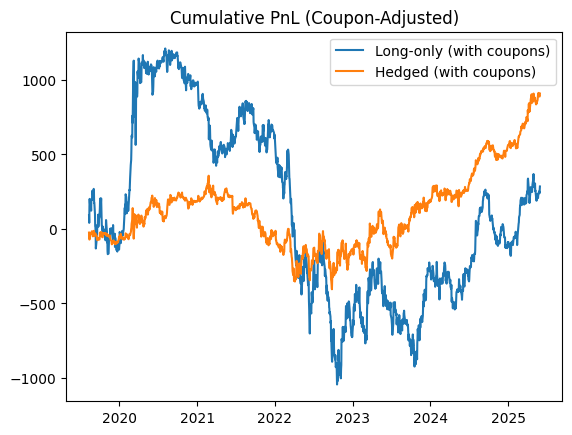

,mean,std,min,max
Long-only (cpn),0.196128,43.721313,-321.203791,276.272207
Hedged (cpn),0.625383,21.194334,-98.341110,118.431025


In [32]:
# -------------------------
# 2.5: Coupon-adjusted PnL (repeat 2.2 but add coupon cashflows)
# -------------------------

pnl_long_cpn = pd.Series(index=idx[1:], dtype=float)
pnl_hedged_cpn = pd.Series(index=idx[1:], dtype=float)

for i in range(1, len(idx)):
    t_prev = pd.Timestamp(idx[i - 1]).normalize()
    t_now = pd.Timestamp(idx[i]).normalize()

    # quantities held over the interval (t_prev -> t_now)
    q1_prev = float(q1.loc[idx[i - 1]])
    q2_prev = float(q2.loc[idx[i - 1]])

    dP1 = float(price2.loc[idx[i], SEC_LONG] - price2.loc[idx[i - 1], SEC_LONG])
    dP2 = float(price2.loc[idx[i], SEC_HEDGE] - price2.loc[idx[i - 1], SEC_HEDGE])

    # coupon paid "on" t_now (mapped to the next quote date),
    # received/paid according to quantities held over the interval
    c1 = float(coupon_cash.loc[t_now, SEC_LONG]) * q1_prev
    c2 = float(coupon_cash.loc[t_now, SEC_HEDGE]) * q2_prev  # if q2_prev < 0, you pay coupons (negative cash)

    pnl_long_cpn.loc[idx[i]] = q1_prev * dP1 + c1
    pnl_hedged_cpn.loc[idx[i]] = q1_prev * dP1 + q2_prev * dP2 + c1 + c2

# plot cumulative coupon-adjusted PnL
plt.figure()
plt.plot(pnl_long_cpn.cumsum(), label="Long-only (with coupons)")
plt.plot(pnl_hedged_cpn.cumsum(), label="Hedged (with coupons)")
plt.title("Cumulative PnL (Coupon-Adjusted)")
plt.legend()
plt.show()

# table of daily PnL stats (coupon-adjusted)
pnl_stats_cpn = pd.DataFrame(
    {
        "mean": [pnl_long_cpn.mean(), pnl_hedged_cpn.mean()],
        "std":  [pnl_long_cpn.std(),  pnl_hedged_cpn.std()],
        "min":  [pnl_long_cpn.min(),  pnl_hedged_cpn.min()],
        "max":  [pnl_long_cpn.max(),  pnl_hedged_cpn.max()],
    },
    index=["Long-only (cpn)", "Hedged (cpn)"]
)
display(pnl_stats_cpn)


***